In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from google.colab import drive
drive.mount('/content/drive')
pd.set_option("display.max_columns", None)

path = "/content/drive/MyDrive/Project Eniac/Data/Data_clean/"

df =pd.read_csv(path + "discount_analysis_final.csv",
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#1. The relationship between Recommended Price and Sold Price

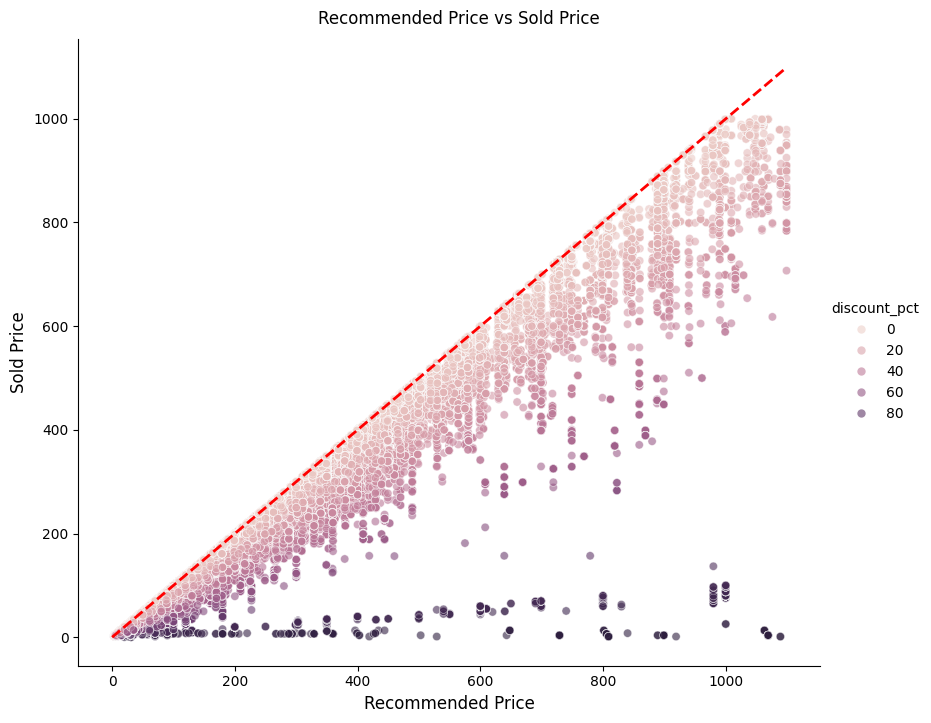

In [14]:
limit = df["price"].quantile(0.99)

g = sns.relplot(
    data=df[df["price"] <= limit],
    x="price",
    y="unit_price",
    hue="discount_pct",
    alpha=0.6,
    height=7,
    aspect=1.2
)

g.set_axis_labels("Recommended Price", "Sold Price", fontsize = 12)
g.fig.suptitle("Recommended Price vs Sold Price", y=1.02)


ax = g.ax


max_price = max(
    df[df["price"] <= limit]["price"].max(),
    df[df["price"] <= limit]["unit_price"].max()
)


ax.plot(
    [0, max_price],
    [0, max_price],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Price = Unit Price"
)

In [15]:
df.head()

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total,price,discount_amount,discount_pct,name,type
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19,18.99,34.99,16.00,45.73,Otterbox iPhone Case Symmetry 2.0 SE / 5s / 5 ...,11865403
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45,399.00,429.00,30.00,6.99,"27UD58-B LG Monitor 27 ""4K UHD DisplayPort",1296
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57,474.05,699.00,224.95,32.18,Parrot Bebop 2 White + Command FLYPAD and FPV ...,11905404
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40,68.39,79.00,10.61,13.43,"Blue WD 2TB Hard Drive 35 ""Mac and PC",12655397
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38,23.74,29.90,6.16,20.60,Gray Bluetooth Speaker JBL GO,5398


# 2 When do customers like to spend more money?


In [16]:
df["date"] = pd.to_datetime(df["date"])

orders_df = (
    df.groupby(["id_order", df["date"].dt.to_period("M")])["unit_price_total"]
      .sum()
      .reset_index()
)

orders_df = orders_df.rename(columns={
    "date": "month",
    "unit_price_total": "total_paid"
})

orders_df["month"] = orders_df["month"].dt.to_timestamp()


In [17]:
avg_order_month = (
    orders_df.groupby("month")["total_paid"]
      .mean()
      .reset_index()
)



Text(0.5, 1.02, 'Average Order Price Over Time')

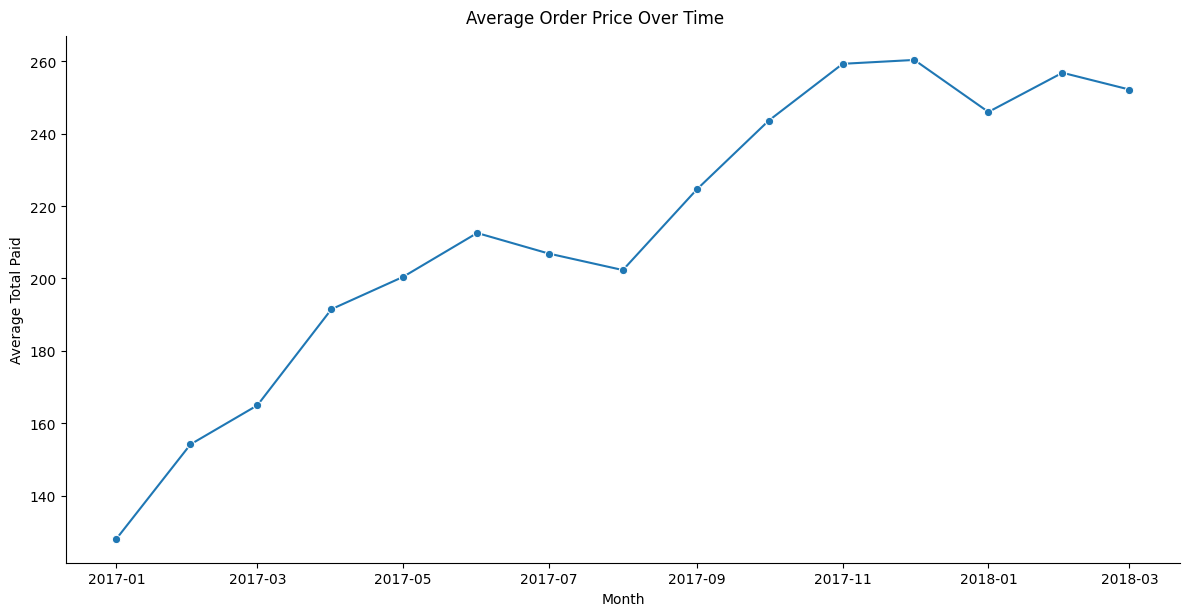

In [18]:
g = sns.relplot(
    data=avg_order_month,
    x="month",
    y="total_paid",
    kind="line",
    marker="o",
    height=6,
    aspect=2
)

g.set_axis_labels("Month", "Average Total Paid")
g.fig.suptitle("Average Order Price Over Time", y=1.02)

The average order value shows an overall upward trend throughout the analyzed period.
Customers tended to spend more money toward the end of 2017, with the highest average order values observed in November and December.
This trend may indicate increased customer spending during the holiday shopping season.

#3. Top 10 Products Sold: January 2017 vs January 2018


In [19]:
jan2017 = df[
    (df["date"].dt.year == 2017) &
    (df["date"].dt.month == 1)
]

jan2018 = df[
    (df["date"].dt.year == 2018) &
    (df["date"].dt.month == 1)
]

In [20]:
top2017 = (
    jan2017.groupby("name")["product_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top2018 = (
    jan2018.groupby("name")["product_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

In [21]:
common_products = set(top2017["name"]) & set(top2018["name"])

In [22]:
top2017["Common"] = top2017["name"].isin(common_products).map({
    True: "Present in both years",
    False: "Only this year"
})

top2018["Common"] = top2018["name"].isin(common_products).map({
    True: "Present in both years",
    False: "Only this year"
})

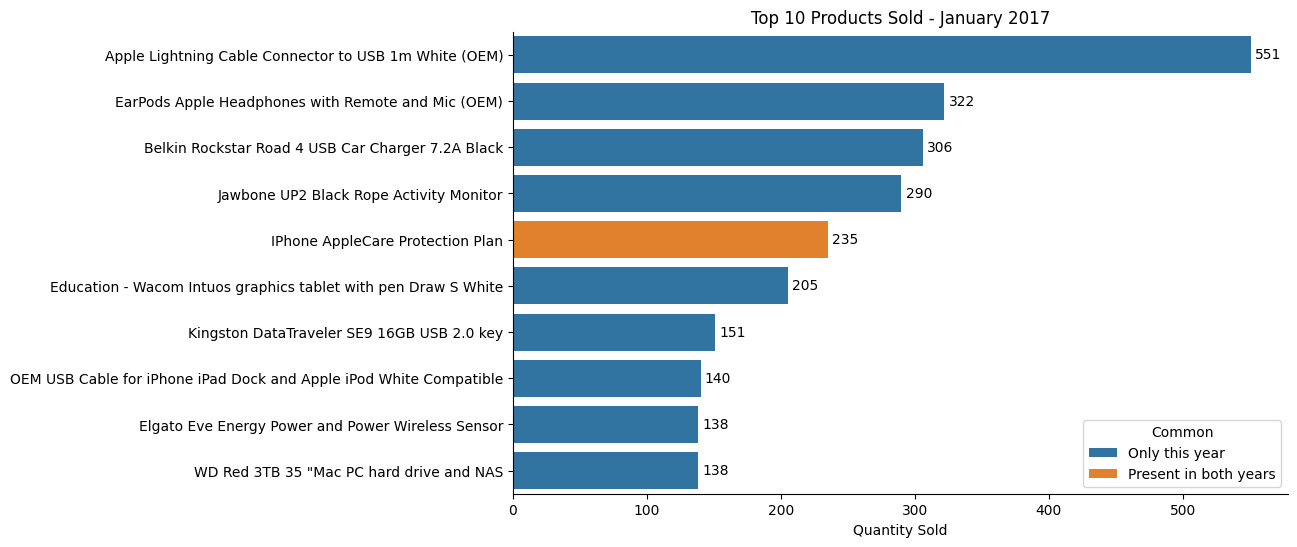

In [23]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top2017,
    x="product_quantity",
    y="name",
    hue="Common"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.title("Top 10 Products Sold - January 2017")
plt.xlabel("Quantity Sold")
plt.ylabel("")

plt.show()

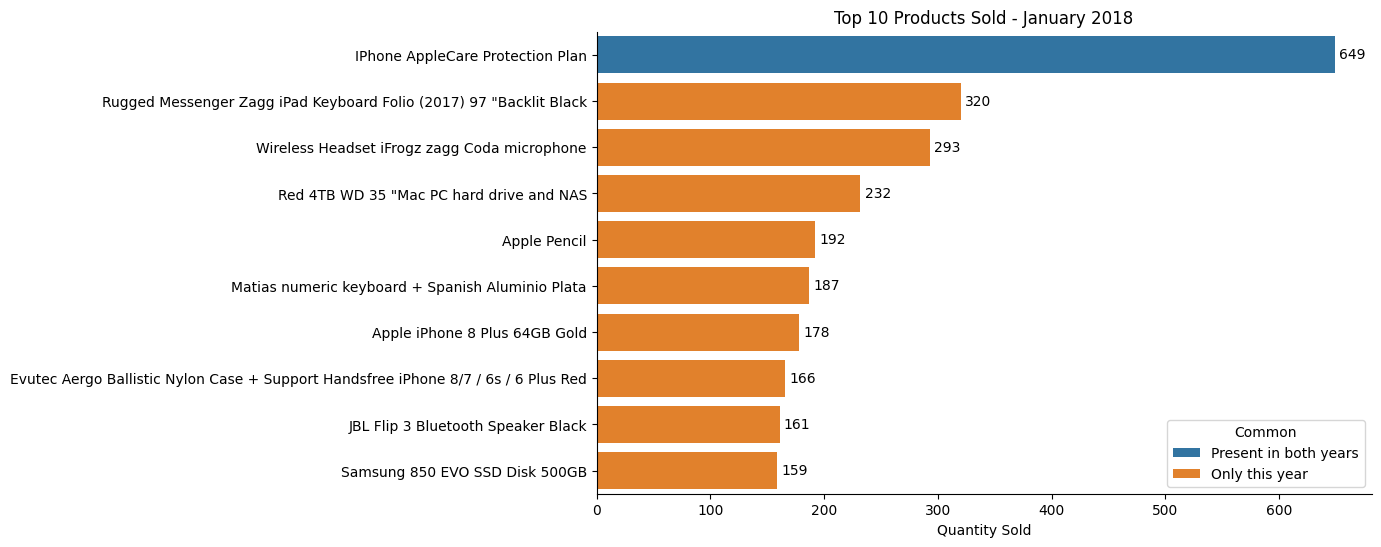

In [24]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top2018,
    x="product_quantity",
    y="name",
    hue="Common"
)

plt.title("Top 10 Products Sold - January 2018")
plt.xlabel("Quantity Sold")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()